<a href="https://colab.research.google.com/github/UBGidado/Social-Graph-Mining/blob/master/notebooks/roberta_twitter_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install networkx scikit-learn transformers

### Imports

In [3]:
import os
import json
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig
from scipy.special import softmax
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load Data

In [5]:
annotation_path = '/content/drive/MyDrive/My Research/Social_Graph_Mining/manual_annotation_goemotions.csv'
df_gold = pd.read_csv(annotation_path)

print(f"\nLoaded {len(df_gold)} manually annotated samples")
print(f"Polarity distribution:\n{df_gold['polarity'].value_counts()}")



Loaded 50 manually annotated samples
Polarity distribution:
polarity
positive    20
neutral     18
negative    12
Name: count, dtype: int64


### Initialize Twitter-RoBERTa Model


In [6]:
print("\nLoading Twitter-RoBERTa sentiment model...")

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
config = AutoConfig.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Label mapping
LABEL_MAP = config.id2label  # {0: 'negative', 1: 'neutral', 2: 'positive'}

print(f"✓ Model loaded: {MODEL_NAME}")
print(f"✓ Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"✓ Labels: {LABEL_MAP}")
print(f"✓ Trained on 124M tweets (good for conversational data)")


Loading Twitter-RoBERTa sentiment model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✓ Model loaded: cardiffnlp/twitter-roberta-base-sentiment-latest
✓ Device: CPU
✓ Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}
✓ Trained on 124M tweets (good for conversational data)


### Enhanced Prediction Function

In [7]:
def predict_sentiment_twitter_roberta(text, return_details=False):
    """
    Predict sentiment using Twitter-RoBERTa with confidence-based strength.

    Args:
        text: Input text
        return_details: If True, return full probability distribution

    Returns:
        tuple: (label, pos_score, neg_score, strength, confidence)
    """
    # Tokenize and encode
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True,
                              max_length=512, padding=True)
    encoded_input = {k: v.to(device) for k, v in encoded_input.items()}

    # Get predictions
    with torch.no_grad():
        output = model(**encoded_input)

    # Get probabilities
    scores = output.logits[0].detach().cpu().numpy()
    probs = softmax(scores)

    # Extract scores
    neg_score = float(probs[0])  # Negative
    neu_score = float(probs[1])  # Neutral
    pos_score = float(probs[2])  # Positive

    # Determine label (argmax)
    label_id = np.argmax(probs)
    label = LABEL_MAP[label_id]

    # Calculate strength
    # Method 1: Use confidence (max probability)
    confidence = float(np.max(probs))

    # Method 2: Polarity strength (distance from neutral)
    if label == 'positive':
        polarity_strength = pos_score - neu_score
    elif label == 'negative':
        polarity_strength = neg_score - neu_score
    else:
        polarity_strength = 0.0

    # Combine both: confidence × polarity strength
    raw_strength = confidence * max(0, polarity_strength + 0.5)

    # Non-linear scaling for better differentiation
    strength = 1 - np.exp(-3.0 * raw_strength)

    if return_details:
        return {
            'label': label,
            'pos_score': pos_score,
            'neg_score': neg_score,
            'neu_score': neu_score,
            'strength': strength,
            'confidence': confidence,
            'polarity_strength': polarity_strength,
            'probs': probs
        }

    return (label, pos_score, neg_score, strength, confidence)


print("\n✓ Enhanced prediction function ready")
print("✓ Strength = confidence × polarity_strength")
print("✓ Accounts for both certainty and intensity")


✓ Enhanced prediction function ready
✓ Strength = confidence × polarity_strength
✓ Accounts for both certainty and intensity


###  Evaluate on Annotated Dataset

In [8]:
print("\nEvaluating on annotated dataset...")

pred_labels = []
pos_scores = []
neg_scores = []
strengths = []
confidences = []

for idx, row in df_gold.iterrows():
    sent = str(row.get('sentence', ''))
    lbl, pos, neg, strength, conf = predict_sentiment_twitter_roberta(sent)

    pred_labels.append(lbl)
    pos_scores.append(pos)
    neg_scores.append(neg)
    strengths.append(strength)
    confidences.append(conf)

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1}/{len(df_gold)} samples...", end='\r')

print(f"\nProcessed {len(df_gold)}/{len(df_gold)} samples... Done!")

df_gold['pred_label'] = pred_labels
df_gold['pos_score'] = pos_scores
df_gold['neg_score'] = neg_scores
df_gold['strength'] = strengths
df_gold['confidence'] = confidences

# Calculate metrics
y_true = df_gold['polarity']
y_pred = df_gold['pred_label']

print("\n" + "=" * 70)
print("EVALUATION RESULTS - TWITTER-ROBERTA")
print("=" * 70)

# Per-class metrics
for label_class in ['positive', 'negative', 'neutral']:
    y_true_bin = [1 if g == label_class else 0 for g in y_true]
    y_pred_bin = [1 if p == label_class else 0 for p in y_pred]

    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    print(f"{label_class.capitalize():8s} -- precision: {prec:.3f}, recall: {rec:.3f}, f1: {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

# Strength statistics
print("\n" + "=" * 70)
print("STRENGTH DISTRIBUTION")
print("=" * 70)
for polarity in ['positive', 'negative', 'neutral']:
    subset = df_gold[df_gold['pred_label'] == polarity]
    if len(subset) > 0:
        print(f"{polarity.capitalize()}: mean={subset['strength'].mean():.3f}, "
              f"std={subset['strength'].std():.3f}, "
              f"range=[{subset['strength'].min():.3f}, {subset['strength'].max():.3f}]")

# Confidence statistics
print("\n" + "=" * 70)
print("CONFIDENCE DISTRIBUTION")
print("=" * 70)
print(f"Overall: mean={df_gold['confidence'].mean():.3f}, "
      f"std={df_gold['confidence'].std():.3f}")
print(f"High confidence (>0.9): {(df_gold['confidence'] > 0.9).sum()} samples")
print(f"Low confidence (<0.5): {(df_gold['confidence'] < 0.5).sum()} samples")



Evaluating on annotated dataset...


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Processed 50/50 samples...
Processed 50/50 samples... Done!

EVALUATION RESULTS - TWITTER-ROBERTA
Positive -- precision: 0.800, recall: 0.400, f1: 0.533
Negative -- precision: 0.667, recall: 0.167, f1: 0.267
Neutral  -- precision: 0.486, recall: 1.000, f1: 0.655

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.17      0.27        12
     neutral       0.49      1.00      0.65        18
    positive       0.80      0.40      0.53        20

    accuracy                           0.56        50
   macro avg       0.65      0.52      0.48        50
weighted avg       0.66      0.56      0.51        50


STRENGTH DISTRIBUTION
Positive: mean=0.934, std=0.090, range=[0.698, 0.986]
Negative: mean=0.825, std=0.104, range=[0.750, 0.943]
Neutral: mean=0.689, std=0.076, range=[0.526, 0.765]

CONFIDENCE DISTRIBUTION
Overall: mean=0.804, std=0.151
High confidence (>0.9): 18 samples
Low confidence (<0.5): 1 samples


### Test Example

In [9]:
example_text = "Bob likes Mary, Mary hates Jane, Jane adores and loves Bob very much."
example_relations = pd.DataFrame([
    {"subject": "Bob", "object": "Mary", "sentence": "Bob likes Mary"},
    {"subject": "Mary", "object": "Jane", "sentence": "Mary hates Jane"},
    {"subject": "Jane", "object": "Bob", "sentence": "Jane adores and loves Bob very much."}
])

print(f"Input: {example_text}\n")

for idx, row in example_relations.iterrows():
    sent = row['sentence']
    result = predict_sentiment_twitter_roberta(sent, return_details=True)

    example_relations.loc[idx, 'linkType'] = result['label']
    example_relations.loc[idx, 'strength'] = result['strength']
    example_relations.loc[idx, 'confidence'] = result['confidence']
    example_relations.loc[idx, 'pos_score'] = result['pos_score']
    example_relations.loc[idx, 'neg_score'] = result['neg_score']

print("Output:")
print(example_relations[['subject', 'object', 'linkType', 'strength', 'confidence']])
print("\nDetailed Scores:")
print(example_relations[['sentence', 'pos_score', 'neg_score', 'strength']])

Input: Bob likes Mary, Mary hates Jane, Jane adores and loves Bob very much.

Output:
  subject object  linkType  strength  confidence
0     Bob   Mary   neutral  0.658404    0.716085
1    Mary   Jane  negative  0.722016    0.591441
2    Jane    Bob  positive  0.984298    0.965039

Detailed Scores:
                               sentence  pos_score  neg_score  strength
0                        Bob likes Mary   0.253076   0.030839  0.658404
1                       Mary hates Jane   0.038627   0.591441  0.722016
2  Jane adores and loves Bob very much.   0.965039   0.004741  0.984298



✓ Saved JSON to /content/drive/MyDrive/My Research/Social_Graph_Mining/twitter_roberta_example_output.json
✓ Saved graph to /content/drive/MyDrive/My Research/Social_Graph_Mining/twitter_roberta_example_graph.png


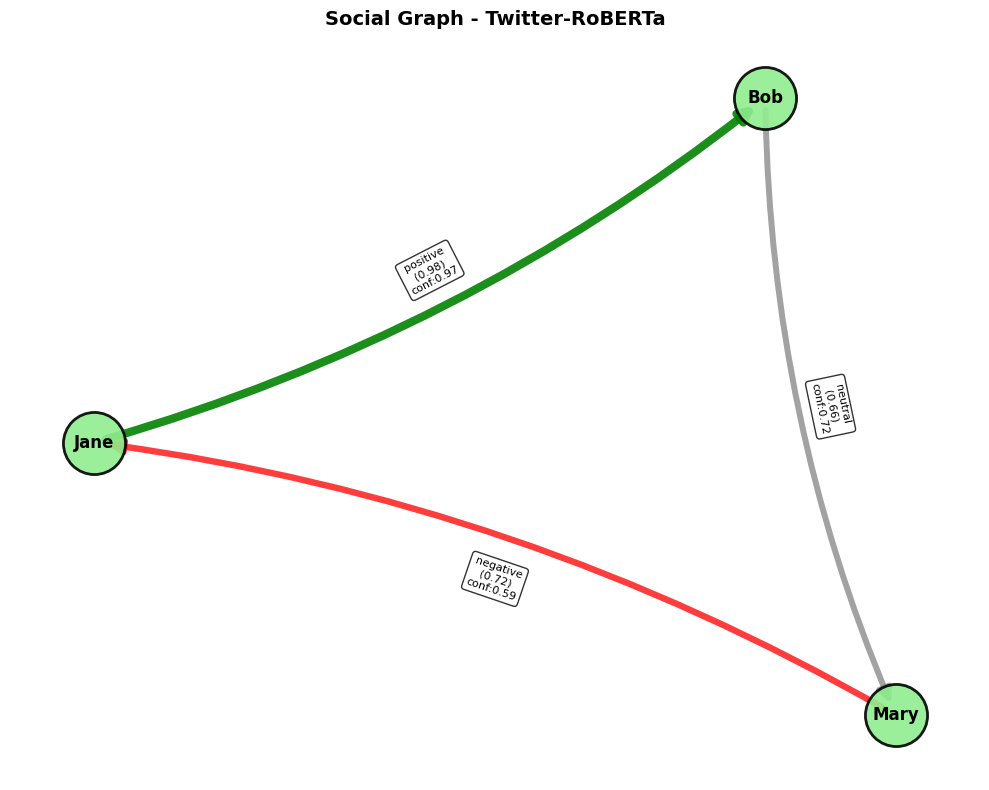


TWITTER-ROBERTA PIPELINE COMPLETE
✓ Evaluated 50 samples
✓ Domain-adapted on 124M tweets (conversational language)
✓ Confidence scores included for uncertainty quantification


In [10]:
# ============================================================
# CELL 6: Generate Social Graph
# ============================================================

def create_social_graph(relations_df, output_json=None, output_png=None):
    """
    Create JSON and visualization for social graph.
    """
    # Create links
    links = []
    for _, row in relations_df.iterrows():
        links.append({
            "source": str(row['subject']),
            "target": str(row['object']),
            "linkType": str(row['linkType']),
            "strength": float(row['strength']),
            "confidence": float(row.get('confidence', 0.0))
        })

    # Save JSON
    if output_json:
        with open(output_json, 'w') as f:
            json.dump(links, f, indent=2)
        print(f"\n✓ Saved JSON to {output_json}")

    # Create graph
    G = nx.DiGraph()
    for link in links:
        G.add_edge(link['source'], link['target'],
                   weight=link['strength'],
                   sentiment=link['linkType'],
                   confidence=link['confidence'])

    # Visualize
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42, k=2)

    # Nodes
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightgreen',
                           alpha=0.9, edgecolors='black', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # Edges with color and width based on sentiment and strength
    for u, v, data in G.edges(data=True):
        color = 'green' if data['sentiment'] == 'positive' else \
                'red' if data['sentiment'] == 'negative' else 'gray'
        width = 1 + 5 * data['weight']
        alpha = 0.4 + 0.5 * data['weight']

        nx.draw_networkx_edges(G, pos, [(u, v)],
                               edge_color=color,
                               width=width,
                               alpha=alpha,
                               arrowsize=20,
                               connectionstyle='arc3,rad=0.1')

    # Edge labels with confidence
    edge_labels = {(u, v): f"{data['sentiment']}\n({data['weight']:.2f})\nconf:{data['confidence']:.2f}"
                   for u, v, data in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                  font_size=8, bbox=dict(boxstyle='round',
                                  facecolor='white', alpha=0.8))

    plt.title("Social Graph - Twitter-RoBERTa", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()

    if output_png:
        plt.savefig(output_png, dpi=200, bbox_inches='tight')
        print(f"✓ Saved graph to {output_png}")

    plt.show()

    return links, G

# Generate graph
links_example, G_example = create_social_graph(
    example_relations,
    output_json='/content/drive/MyDrive/My Research/Social_Graph_Mining/twitter_roberta_example_output.json',
    output_png='/content/drive/MyDrive/My Research/Social_Graph_Mining/twitter_roberta_example_graph.png'
)

print("\n" + "=" * 70)
print("TWITTER-ROBERTA PIPELINE COMPLETE")
print("=" * 70)
print(f"✓ Evaluated {len(df_gold)} samples")
print(f"✓ Domain-adapted on 124M tweets (conversational language)")
print(f"✓ Confidence scores included for uncertainty quantification")

## Models comparison

In [25]:
results = {
    "Model": ["PyGENTS", "RoBERTa-GoEmotions", "Twitter-RoBERTa"],

    "Acc": [0.52, 0.54, 0.56],

    "F1_Pos": [0.533, 0.500, 0.533],
    "F1_Neg": [0.348, 0.250, 0.267],
    "F1_Neu": [0.625, 0.654, 0.655]
}

df_results = pd.DataFrame(results)

# Compute Macro Average F1
df_results["Macro_F1"] = df_results[["F1_Pos", "F1_Neg", "F1_Neu"]].mean(axis=1)

df_results


,Model,Acc,F1_Pos,F1_Neg,F1_Neu,Macro_F1
0,PyGENTS,0.52,0.533,0.348,0.625,0.502
1,RoBERTa-GoEmotions,0.54,0.500,0.250,0.654,0.468
2,Twitter-RoBERTa,0.56,0.533,0.267,0.655,0.485


## F1 scores comparison

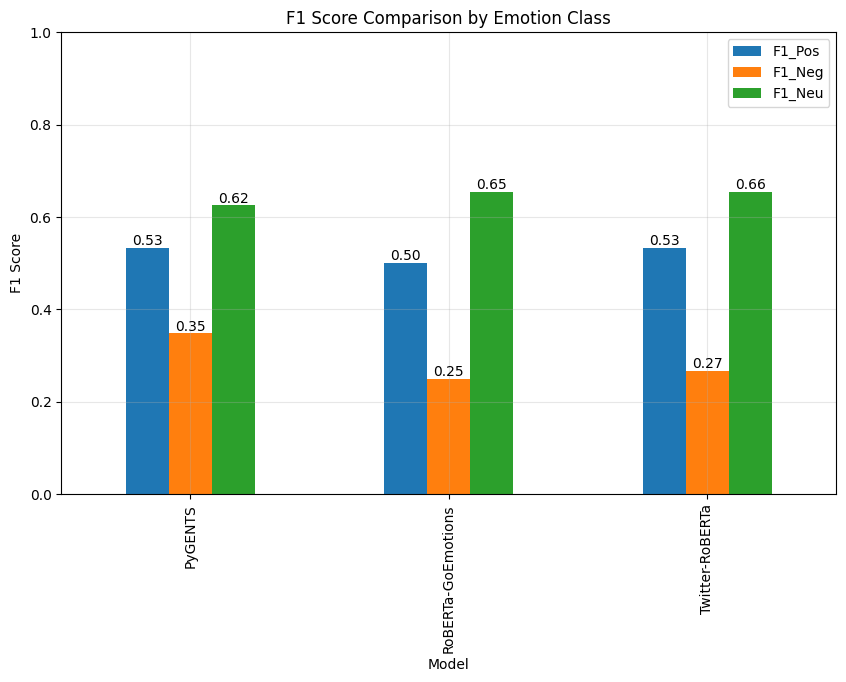

In [20]:
import matplotlib.pyplot as plt

df_f1 = df_results[["Model", "F1_Pos", "F1_Neg", "F1_Neu"]].set_index("Model")

ax = df_f1.plot(kind="bar", figsize=(10,6))
plt.title("F1 Score Comparison by Emotion Class")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

# Add value labels on bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', label_type='edge')

plt.show()


### Accuracy & Macro Average F1 Score comparison

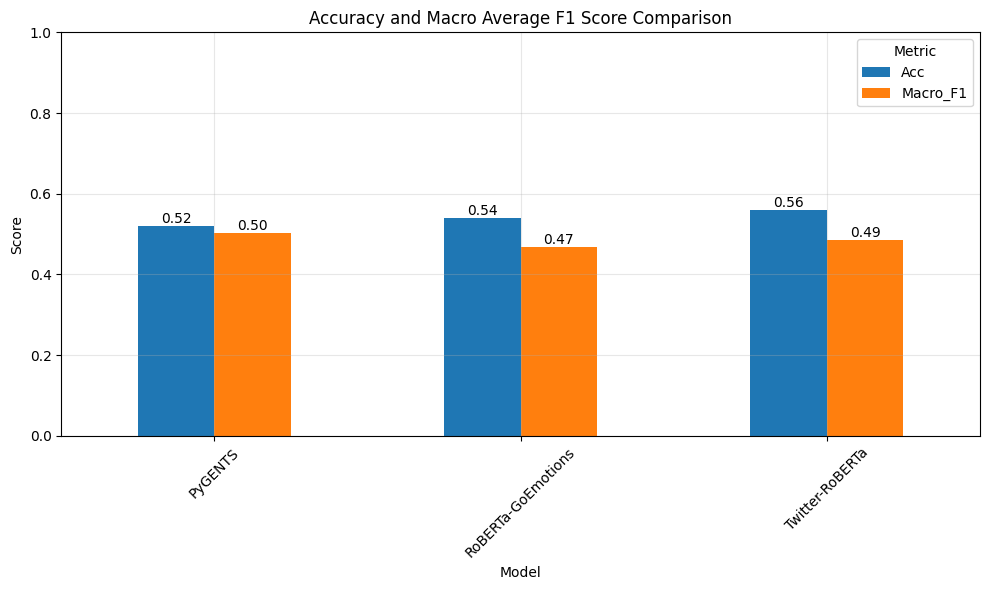

In [26]:
ax_combined = df_results.set_index("Model")[["Acc", "Macro_F1"]].plot(kind="bar", figsize=(10,6), rot=45)
plt.title("Accuracy and Macro Average F1 Score Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

for container in ax_combined.containers:
    ax_combined.bar_label(container, fmt='%.2f', label_type='edge')

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [28]:
!jupyter nbconvert --ClearOutputPreprocessor.enabled=True \
    --to notebook \
    --inplace roberta_twitter_model.ipynb


[NbConvertApp] WARNING | pattern 'roberta_twitter_model.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--e